# 02. Análise Estatística e Distribuições

Análise demográfica de pulsares do ATNF e distribuições (Recuperação Exata do trabalho manual).

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# caminho relativo
BASE = Path("../../").resolve()

RAW_DIR    = BASE / "data" / "raw" / "atnf_raw_arquivos"
INTERIM_DIR = BASE / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

# carrega o arquivo
arquivo = RAW_DIR / "atnf_catalog_raw_2026-08-21.csv"
print(f"Carregando: {arquivo.name}")

df = pd.read_csv(arquivo)
print(f"{df.shape[0]} estrelas, {df.shape[1]} colunas")
df.head()


Carregando: atnf_catalog_raw_2026-08-21.csv
4303 estrelas, 23 colunas


,GB,S1400_ERR,P1_ERR,RAJ,AGE,DM_ERR,JNAME,DECJ,PB,ASSOC,...,P0_ERR,GL,DIST,S1400,P0,EDOT,PB_ERR,RAJ_ERR,DM,DECJ_ERR
0,-0.073821,NaN,6.654376e-20,00:02:58.17,3.063207e+05,0.6,J0002+6216,+62:16:09.4,NaN,GRS,...,1.330875e-12,117.326628,6.357,0.022,0.115364,1.534306e+35,NaN,0.02,218.6,0.1
1,-42.984988,NaN,1.200000e-17,00:06:04.8,5.241664e+06,0.6,J0006+1834,+18:34:59,NaN,NaN,...,1.400000e-10,108.172136,0.860,NaN,0.693748,2.479440e+32,NaN,0.20,11.4,4.0
2,10.463079,NaN,4.988794e-17,00:07:01.7,1.388691e+04,NaN,J0007+7303,+73:03:07.4,NaN,GRS,...,2.993276e-10,119.659601,1.400,NaN,0.315873,4.514345e+35,NaN,0.20,NaN,0.8
3,-53.407050,NaN,NaN,00:11:34,NaN,NaN,J0011+08,+08:10,NaN,NaN,...,NaN,106.228269,5.399,NaN,2.552870,NaN,NaN,31.00,24.9,8.0
4,-7.911120,NaN,NaN,00:12:23.3,3.740843e+08,0.7,J0012+5431,+54:31:40,NaN,NaN,...,1.830489e-10,117.230523,5.427,NaN,3.025301,1.826919e+29,NaN,0.10,131.3,9.0


## 1. Inspeção das Categorias Originais

O catálogo ATNF fornece diversas classificações na coluna `TYPE`. Para uma **análise de dados robusta**, precisamos entender como essas categorias estão distribuídas antes de iniciar qualquer modelagem ou estatística.

In [19]:
# vendo o que existe na coluna TYPE (referente ao tipo de estrela segundo o ATNF)

print("valores unicos na coluna TYPE:")
print(df["TYPE"].value_counts(dropna=False).head(30))


valores unicos na coluna TYPE:
TYPE
NaN     3708
HE       250
RRAT     220
NRAD      93
AXP       24
XINS       8
Name: count, dtype: int64


## 2. Feature Engineering: Consolidação de Tipos

As categorias originais do ATNF são muito granulares (muitas subcategorias com poucos dados). Para viabilizar a análise estatística, vamos criar uma nova coluna `tipo_principal` consolidando essas classificações baseadas nas propriedades físicas fundamentais dos objetos:

- **Magnetar (AXP)**: Estrelas com campos magnéticos extremos (Anomalous X-ray Pulsars).
- **XINS**: Estrelas de nêutrons isoladas que emitem raios-X (X-ray Isolated Neutron Stars).
- **RRAT**: Fontes de rádio transientes e esporádicas (Rotating Radio Transients).
- **NRAD**: Pulsares que não emitem ondas de rádio (Radio-quiet).
- **HE**: Pulsares emissores de altas energias, como raios gama (High-Energy).
- **MSP (Millisecond Pulsars)**: Pulsares com rotação extremamente rápida. Como o catálogo muitas vezes omite essa tag explicitamente, usamos o limiar físico de **Período de Rotação (`P0`) < 0.03 segundos** para inferir essa classe matematicamente.
- **Normal**: Todos os demais pulsares canônicos de disco.

In [20]:
# renomeando os tipos e aprimorando a categorização para um tipo extra

def classificar_tipo(row):
    tipo = row["TYPE"]
    periodo = row["P0"]

    # magnetares
    if pd.notna(tipo) and "AXP" in str(tipo):
        return "magnetar"
    # tipos com tag explicito
    if pd.notna(tipo) and "XINS" in str(tipo):
        return "XINS"
    if pd.notna(tipo) and "RRAT" in str(tipo):
        return "RRAT"
    if pd.notna(tipo) and "NRAD" in str(tipo):
        return "NRAD"
    if pd.notna(tipo) and "HE" in str(tipo):
        return "HE"
    # MSP: derivado do periodo (sem tag no catalogo)
    if pd.notna(periodo) and periodo < 0.03:
        return "MSP"
    # todos os demais: pulsares normais
    return "normal"

df ["tipo_principal"] = df.apply(classificar_tipo, axis=1)

print ("distribuição final:")
print(df["tipo_principal"].value_counts())


distribuição final:
tipo_principal
normal      3100
MSP          608
HE           250
RRAT         220
NRAD          93
magnetar      24
XINS           8
Name: count, dtype: int64


## 3. Distribuições Estatísticas (Escala Logarítmica)

Parâmetros astrofísicos como Período ($P$), Derivada do Período ($\dot{P}$), Idade e Campo Magnético variam em **múltiplas ordens de grandeza**. Por isso, utilizar a escala logarítmica ($\log_{10}$) é crucial para normalizar as distribuições e visualizar as diferenças entre as subpopulações de forma clara.

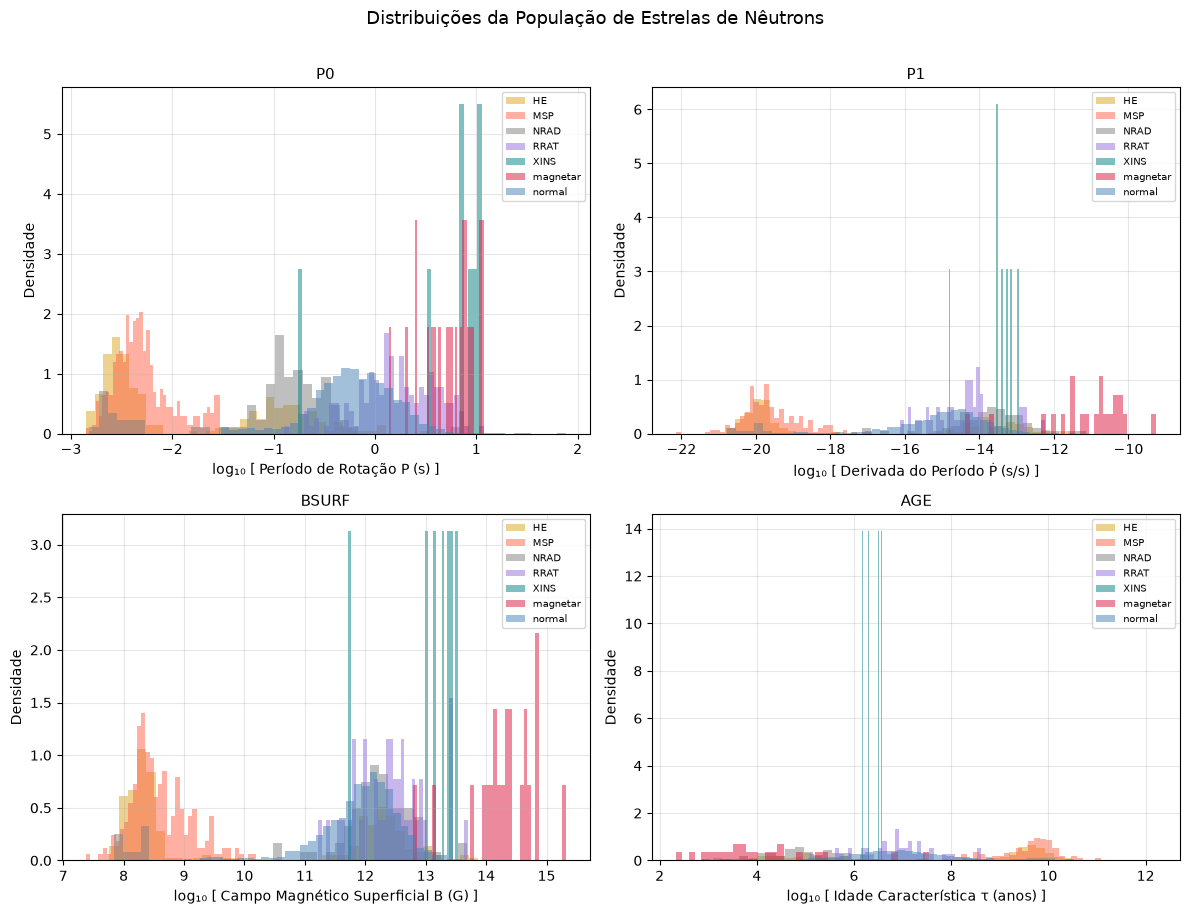

In [21]:
import matplotlib.pyplot as plt

PARAMS_LOG = {
    "P0":    "Período de Rotação P (s)",
    "P1":    "Derivada do Período Ṗ (s/s)",
    "BSURF": "Campo Magnético Superficial B (G)",
    "AGE":   "Idade Característica τ (anos)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

cores = {
    "normal": "steelblue",
    "MSP":    "tomato",
    "HE":     "goldenrod",
    "RRAT":   "mediumpurple",
    "NRAD":   "gray",
    "magnetar": "crimson",
    "XINS":   "teal",
}

for ax, (col, label) in zip(axes, PARAMS_LOG.items()):
    for tipo, grupo in df.groupby("tipo_principal"):
        dados = grupo[col].dropna()
        dados = dados[dados > 0]  # log não aceita zero ou negativo
        if len(dados) < 5:
            continue
        ax.hist(
            np.log10(dados),
            bins=40,
            alpha=0.5,
            label=tipo,
            color=cores.get(tipo, "black"),
            density=True
        )
    ax.set_xlabel(f"log₁₀ [ {label} ]", fontsize=10)
    ax.set_ylabel("Densidade", fontsize=10)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribuições da População de Estrelas de Nêutrons", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(BASE / "figures" / "01_distributions_by_type.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Diagrama P-$\dot{P}$ (O "Diagrama HR" dos Pulsares)

O diagrama $P-\dot{P}$ relaciona o Período de Rotação com a sua taxa de desaceleração. Ele funciona como o equivalente do Diagrama de Hertzsprung-Russell (HR) para estrelas normais, permitindo visualizar o caminho evolutivo dos pulsares. Note como os **MSP** formam uma "ilha" isolada no canto inferior esquerdo (rápida rotação, baixa desaceleração) e os **Magnetares** ficam no canto superior direito.

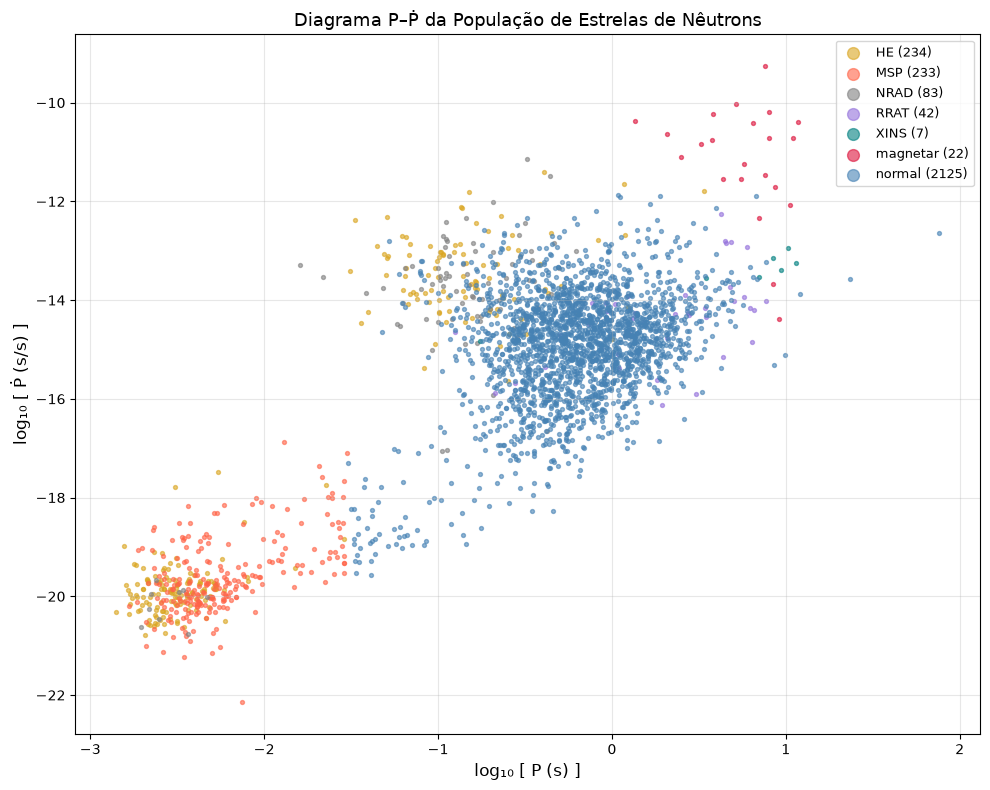

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))

for tipo, grupo in df.groupby("tipo_principal"):
    dados = grupo[["P0", "P1"]].dropna()
    dados = dados[(dados["P0"] > 0) & (dados["P1"] > 0)]
    ax.scatter(
        np.log10(dados["P0"]),
        np.log10(dados["P1"]),
        s=8,
        alpha=0.6,
        label=f"{tipo} ({len(dados)})",
        color=cores.get(tipo, "black")
    )

ax.set_xlabel("log₁₀ [ P (s) ]", fontsize=12)
ax.set_ylabel("log₁₀ [ Ṗ (s/s) ]", fontsize=12)
ax.set_title("Diagrama P–Ṗ da População de Estrelas de Nêutrons", fontsize=13)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE / "figures" / "02_ppdot_diagram.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Distribuição Espacial (Coordenadas Galácticas)

Utilizando a projeção de Mollweide, mapeamos a posição das estrelas usando Longitude ($l$) e Latitude ($b$) galácticas. A maioria esmagadora da população jovem ("normal") deve se concentrar no plano galáctico (linha equatorial do gráfico, $b \approx 0$), enquanto pulsares muito antigos ou reciclados (como os MSPs) podem estar espalhados no halo galáctico.

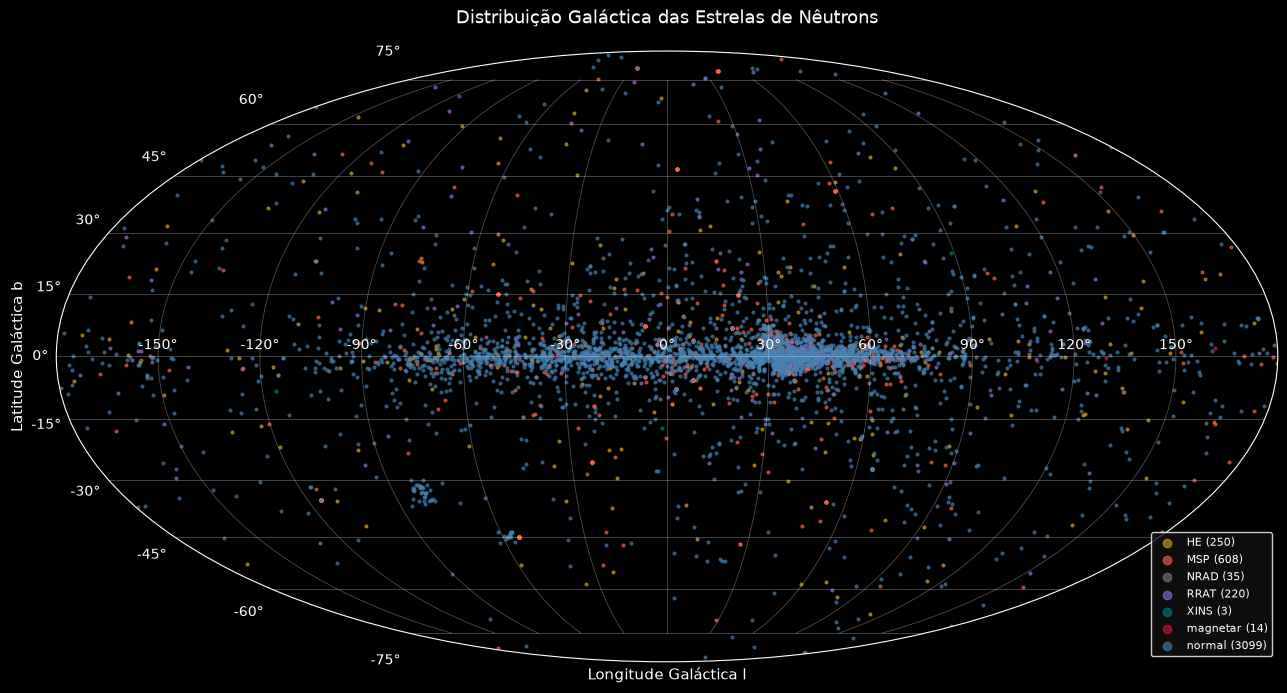

In [ ]:
fig = plt.figure(figsize=(13, 7), facecolor="black")
ax = fig.add_subplot(111, projection="mollweide")
ax.set_facecolor("black")

for tipo, grupo in df.groupby("tipo_principal"):
    dados = grupo[["GL", "GB"]].dropna()

    l = dados["GL"].copy()
    l[l > 180] = l[l > 180] - 360
    l_rad = np.deg2rad(l)
    b_rad = np.deg2rad(dados["GB"])

    ax.scatter(
        l_rad, b_rad,
        s=4,
        alpha=0.6,
        label=f"{tipo} ({len(dados)})",
        color=cores.get(tipo, "black")
    )

ax.set_xlabel("Longitude Galáctica l", fontsize=11, color="white")
ax.set_ylabel("Latitude Galáctica b", fontsize=11, color="white")
ax.set_title("Distribuição Galáctica das Estrelas de Nêutrons",
             fontsize=13, pad=20, color="white")

# grid branco
ax.grid(True, color="white", alpha=0.3, linewidth=0.6)

# ticks e labels dos eixos em branco
ax.tick_params(colors="white")
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color("white")

# borda da projeção em branco
for spine in ax.spines.values():
    spine.set_edgecolor("white")

legend = ax.legend(fontsize=8, markerscale=3, loc="lower right",
                   facecolor="#111111", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.savefig(BASE / "figures" / "03_sky_map_galactic.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## 6. Buscando Aglomerados Globulares

Aqui eu fiquei curioso pois a distrubuição de estrelas de neutrons no mapa mostra dois aglomerados fora do nosso plano galactico, vou investigar todos os aglomerados (prefixo repetido no nome do objeto) buscando identificar o que pode ser cada um (você pode ver esse grafico como uma imagem do céu varias estrelas na via lactea e algumas estrelas mais isoladas fora dela).

In [33]:
# isolar estrelas abaixo de b < -20° (fora do plano galáctico)
fora_do_plano = df[df["GB"] < -20].copy()

print(f"Total de estrelas com GB < -20°: {len(fora_do_plano)}")
print()
print("Associações encontradas (ASSOC):")
print(fora_do_plano["ASSOC"].value_counts(dropna=False).head(20))


Total de estrelas com GB < -20°: 349

Associações encontradas (ASSOC):
ASSOC
NaN      198
GC        66
EXGAL     46
GRS       36
OPT        3
Name: count, dtype: int64


In [34]:
tuc47 = df[df["JNAME"].str.startswith("J0024-7204")]

print(f"Pulsares do 47 Tuc encontrados: {len(tuc47)}")
print(tuc47[["JNAME", "GL", "GB", "P0", "tipo_principal"]])


Pulsares do 47 Tuc encontrados: 27
           JNAME          GL         GB        P0 tipo_principal
8    J0024-7204C  305.923457 -44.892181  0.005757            MSP
9    J0024-7204D  305.880630 -44.893311  0.005358            MSP
10   J0024-7204E  305.883477 -44.882811  0.003536            MSP
11   J0024-7204F  305.898632 -44.891676  0.002624            MSP
12   J0024-7204G  305.891469 -44.893319  0.004040            MSP
13   J0024-7204H  305.895646 -44.902113  0.003210            MSP
14   J0024-7204I  305.891516 -44.893320  0.003485            MSP
15   J0024-7204J  305.909182 -44.902913  0.002101            MSP
16   J0024-7204L  305.897953 -44.887787  0.004346            MSP
17   J0024-7204M  305.912561 -44.876710  0.003677            MSP
18   J0024-7204N  305.889904 -44.896524  0.003054            MSP
19   J0024-7204O  305.896563 -44.888822  0.002643            MSP
20   J0024-7204P  305.871647 -44.903775  0.003643            MSP
21   J0024-7204Q  305.877048 -44.898942  0.004033      

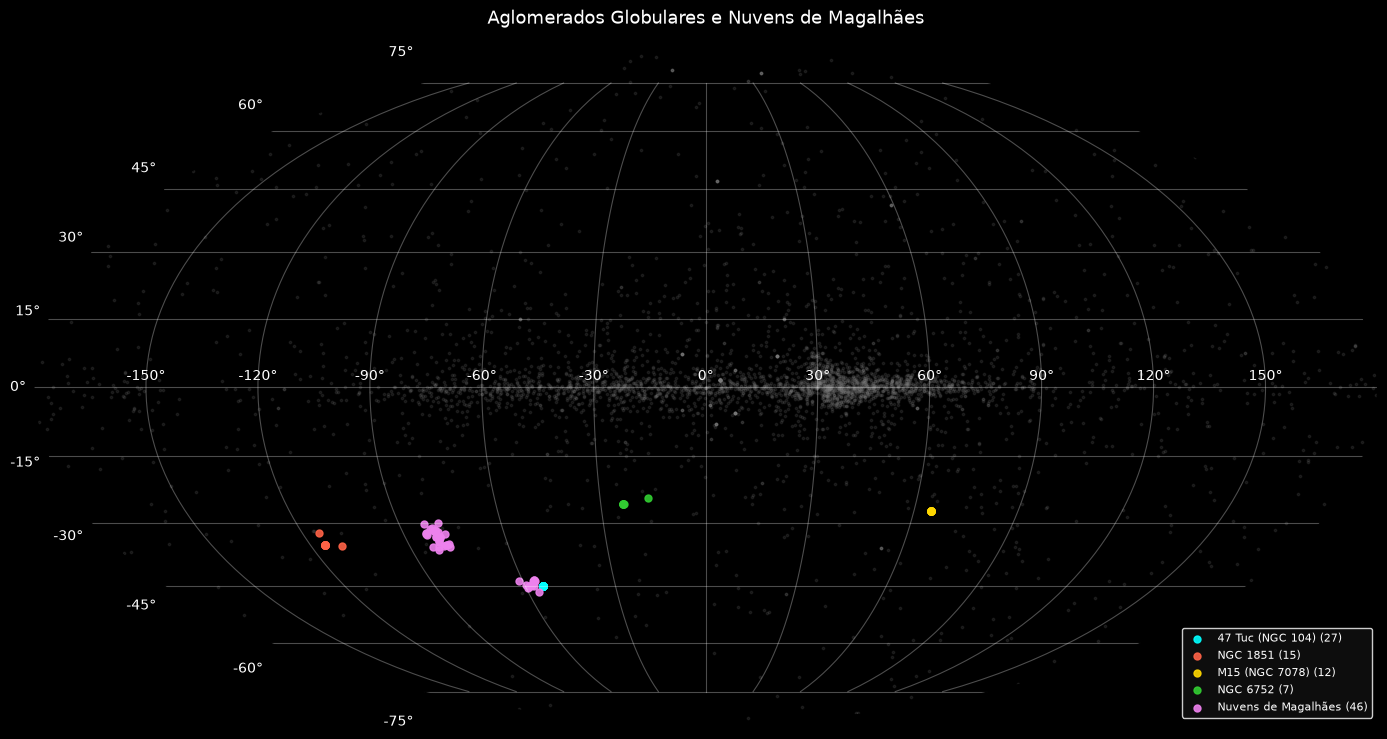

In [ ]:
# definir os grupos de interesse com nome e prefixo/filtro
clusters = {
    "47 Tuc (NGC 104)":  df["JNAME"].str.startswith("J0024-7204"),
    "NGC 1851":          df["JNAME"].str.startswith("J0514-4"),
    "M15 (NGC 7078)":    df["JNAME"].str.startswith("J2129+1"),
    "NGC 6752":          df["JNAME"].str.startswith("J1910-5"),
    "Nuvens de Magalhães": df["ASSOC"] == "EXGAL",
}

cores_clusters = {
    "47 Tuc (NGC 104)":    "cyan",
    "NGC 1851":            "tomato",
    "M15 (NGC 7078)":      "gold",
    "NGC 6752":            "limegreen",
    "Nuvens de Magalhães": "violet",
}

# mascara de tudo que é cluster (para separar do fundo)
mascara_clusters = clusters["47 Tuc (NGC 104)"].copy()
for mask in clusters.values():
    mascara_clusters = mascara_clusters | mask

fundo = df[~mascara_clusters]

fig = plt.figure(figsize=(14, 8), facecolor="black")
ax = fig.add_subplot(111, projection="mollweide")
ax.set_facecolor("black")

# fundo em cinza
l_fundo = fundo["GL"].copy()
l_fundo[l_fundo > 180] = l_fundo[l_fundo > 180] - 360
ax.scatter(np.deg2rad(l_fundo), np.deg2rad(fundo["GB"]),
           s=3, alpha=0.15, color="gray")

# clusters em cores
for nome, mascara in clusters.items():
    grupo = df[mascara]
    l = grupo["GL"].copy()
    l[l > 180] = l[l > 180] - 360
    ax.scatter(
        np.deg2rad(l), np.deg2rad(grupo["GB"]),
        s=25, alpha=0.9,
        color=cores_clusters[nome],
        label=f"{nome} ({len(grupo)})"
    )

ax.grid(True, color="white", alpha=0.3)
ax.tick_params(colors="white")
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color("white")
ax.set_title("Aglomerados Globulares e Nuvens de Magalhães",
             color="white", fontsize=13, pad=20)
ax.legend(fontsize=8, facecolor="#111111",
          edgecolor="white", labelcolor="white", loc="lower right")

plt.tight_layout()
plt.savefig(BASE / "figures" / "04_clusters_identified.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()


## Identificando um achado muito legal.

O que pareciam dois aglomerados suspeitos em latitudes galácticas
negativas revelou ser uma sobreposição de estruturas em distâncias
completamente diferentes:

- **47 Tucanae** (~4,5 kpc) — aglomerado globular da Via Láctea
- **SMC e LMC** (~60–50 kpc) — galáxias satélites da Via Láctea (**Nuvens de Magalhães**)

O catálogo ATNF inclui pulsares extragalácticos detectados nas
Nuvens de Magalhães. Eles aparecem colados ao 47 Tuc no mapa porque
a projeção 2D não carrega informação de distância, apenas direção.

De qualquer forma, é muito legal visualizar as Nuvens de Magalhães de forma tão nitida nesses dados apenas visualizando a posição desse tipo de estrela em especifico.


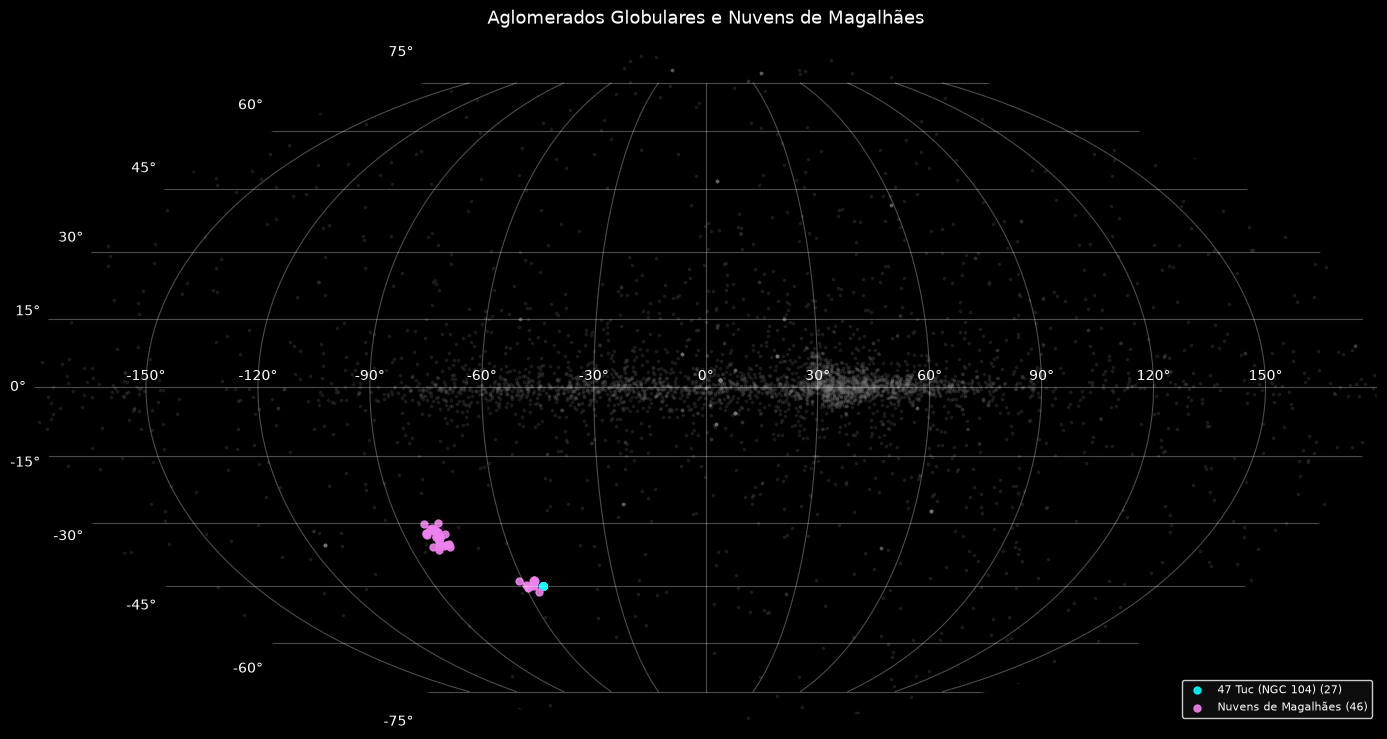

In [38]:
clusters = {
    "47 Tuc (NGC 104)":  df["JNAME"].str.startswith("J0024-7204"),
    "Nuvens de Magalhães": df["ASSOC"] == "EXGAL",
}

cores_clusters = {
    "47 Tuc (NGC 104)":    "cyan",
    "Nuvens de Magalhães": "violet",
}

# mascara de tudo que é cluster (para separar do fundo)
mascara_clusters = clusters["47 Tuc (NGC 104)"].copy()
for mask in clusters.values():
    mascara_clusters = mascara_clusters | mask

fundo = df[~mascara_clusters]

fig = plt.figure(figsize=(14, 8), facecolor="black")
ax = fig.add_subplot(111, projection="mollweide")
ax.set_facecolor("black")

# fundo em cinza
l_fundo = fundo["GL"].copy()
l_fundo[l_fundo > 180] = l_fundo[l_fundo > 180] - 360
ax.scatter(np.deg2rad(l_fundo), np.deg2rad(fundo["GB"]),
           s=3, alpha=0.15, color="gray")

# clusters em cores
for nome, mascara in clusters.items():
    grupo = df[mascara]
    l = grupo["GL"].copy()
    l[l > 180] = l[l > 180] - 360
    ax.scatter(
        np.deg2rad(l), np.deg2rad(grupo["GB"]),
        s=25, alpha=0.9,
        color=cores_clusters[nome],
        label=f"{nome} ({len(grupo)})"
    )

ax.grid(True, color="white", alpha=0.3)
ax.tick_params(colors="white")
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color("white")
ax.set_title("Aglomerados Globulares e Nuvens de Magalhães",
             color="white", fontsize=13, pad=20)
ax.legend(fontsize=8, facecolor="#111111",
          edgecolor="white", labelcolor="white", loc="lower right")

plt.tight_layout()
plt.savefig(BASE / "figures" / "04_clusters_identified.png",
            dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
